<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week11/Day6/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge: Breast Cancer Prediction**

**Your Task**
* Exploratory Data Analysis:
  * Use pandas to load the dataset and examine the first few rows.
  * Check and handle the missing values.
  * Drop any unnecessary column
  * Create a Countplot to display diagnosis from magma

* Data Preprocessing, Building Models and Evaluation :
  * counts of unique rows in the ‘diagnosis’ column
  * map categorical values to numerical values
  * Splitting the data into train and test
  * Implement logistic regression and print the accuracy.
  * Implement K Nearest Neighbours and print the accuracy.
  * Implement Random Forests and print the accuracy.
  * Implement Support Vector Machines (SVM) and print the accuracy.
  * Which is the best model ?

# **Breast Cancer Dataset**

**Introduction**

This dataset contains information on breast tumors.

Each record is a digitized image of a biopsy; the target is the diagnosis variable, and each tumor is classified as follows:

* Benign (non-cancerous) ~ 0
* Malignant (cancerous) ~ 1

Each observation includes various numerical variables that describe cell characteristics, such as size, texture, and shape.

With this data, it is possible to train machine learning classification models and evaluate how well they can predict the diagnosis.

In [14]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print ("imports completed!")

imports completed!


# Load Data & Exploratory Data Analysis

In [15]:
# load the CSV into a DataFrame
df = pd.read_csv('data_breast_cancer.csv')

# inspect df

# examine the first few rows
print ('\nfirst 5 rows')
print(df.head())

print ('\nShape database')  # dataset of 569 patients x 32 columns
print(df.shape)

print()
print(f'Duplicates: {df.duplicated().sum()}')  #no duplicates

# Check and handle the missing values
print ('\nInfo')
print(df.info())     # No missing values ​​were found


first 5 rows
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_w

In [16]:
# Drop any unnecessary column --> delete id
df = df.drop(columns=['id'], errors='ignore')

In [17]:
'''For each of the 10 measurements, three versions are presented (mean, se and worst);
it was decided to keep all of them to preserve the maximum available information.'''

mean_features = list (df.columns[1:11])
#  1   radius_mean
#  2   texture_mean
#  3   perimeter_mean
#  4   area_mean
#  5   smoothness_mean
#  6   compactness_mean
#  7   concavity_mean
#  8   concave points_mean
#  9  symmetry_mean
#  10  fractal_dimension_mean

se_features = list (df.columns[11:21])
#  11  radius_se
#  12  texture_se
#  13  perimeter_se
#  14  area_se
#  15  smoothness_se
#  16  compactness_se
#  17  concavity_se
#  18  concave points_se
#  19  symmetry_se
#  20  fractal_dimension_se

worst_features = list (df.columns[21:32])
#  21  radius_worst
#  22  radius_worst
#  23  texture_worst
#  24  perimeter_worst
#  25  area_worst
#  26  smoothness_worst
#  27  compactness_worst
#  28  concavity_worst
#  29  concave points_worst
#  30  symmetry_worst
#  31  fractal_dimension_worst

In [18]:
# map categorical values to numerical values
# B → benign (non-cancerous)    0
# M → malignant (cancer)    1

df['diagnosis']  = df['diagnosis'].map({'B': 0, 'M': 1})   # Modify original df

'''The positive class (1) was assigned to malignant tumors because in a medical context
 it is a priority to correctly detect cases of cancer.'''

# target column
target = 'diagnosis'  # what I want to predict

# Correlation Analysis

In [19]:
corr = df.corr(numeric_only=True)

# Correlation only with diagnosis
corr_target = corr['diagnosis'].sort_values(ascending=False)

# filter strong (positive or negative)
strong_corr = corr_target[(corr_target > 0.60) | (corr_target < -0.60)]
print(strong_corr)

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


In [20]:
# Target Exploration

counts = df[target].value_counts()
percent = df[target].value_counts(normalize=True) * 100

df_summary = pd.DataFrame({
    'count': counts,
    'percentage': percent.round(1)
})

# counts of unique rows in the ‘diagnosis’ column
print ('Diagnosis Distribution')
print(df_summary)

Diagnosis Distribution
           count  percentage
diagnosis                   
0            357        62.7
1            212        37.3


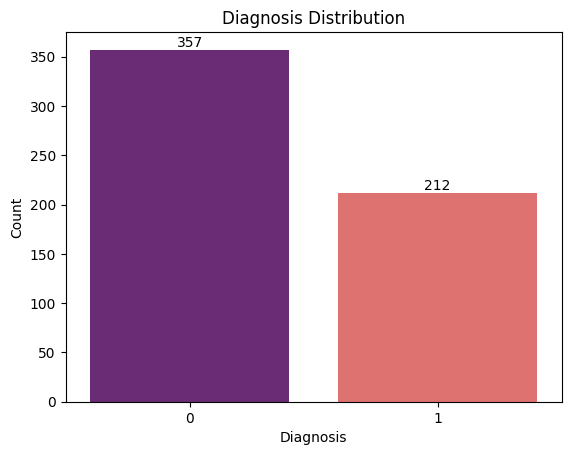

In [21]:
# Create a Countplot to display diagnosis from magma => class balance

ax = sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='magma', legend=False)

for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom'
    )

plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

# B → benign (non-cancerous)    0
# M → malignant (cancer)    1

# Data Preprocessing, Building Models and Evaluation

In [22]:
# split features and target
X = df.drop(columns=[target])
y = df[target]

# Splitting data into train and test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,       # independent variables
    y,       # target variable
    test_size=0.2,
    random_state=RANDOM_STATE, #42
    stratify=y  #same proportion, maintaining the class ratio
)

print()
print("Train shape:", X_train.shape)  # 80%
print("Test shape:", X_test.shape)    # 20%

print()
display(y_train.mean().round(3)) # ~0.374
display(y_test.mean().round(3))  # ~0.368


Train shape: (455, 30)
Test shape: (114, 30)



np.float64(0.374)

np.float64(0.368)

# Preprocessing (Scaler)

In [25]:
pre = ColumnTransformer([
    ('num', StandardScaler(), X.columns)
])

# Helper - Evaluation Function

In [24]:
# reusable function

def eval_model(name, model, X_test, y_test):
    """Compute metrics + draw confusion matrix and ROC if available."""

    y_pred = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    print(f"\n{name}")
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(5,5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc='lower right')
        plt.show()

    return metrics

# Logistic Regression


Logistic Regression
accuracy: 0.965
precision: 0.975
recall: 0.929
f1: 0.951


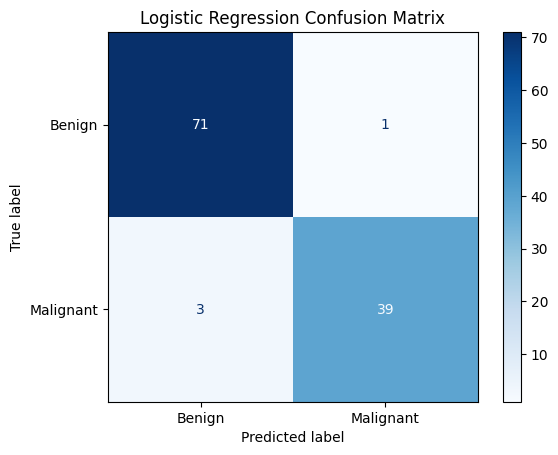

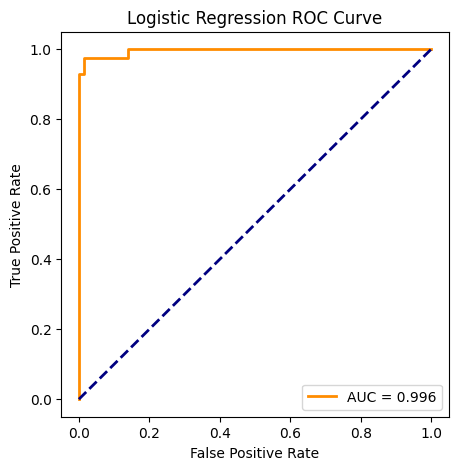

In [26]:
# Pipeline
pipe_lr = Pipeline([
    ('pre', pre),      # scaling
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))   #model
])

pipe_lr.fit(X_train, y_train)  #Training part

lr_metrics = eval_model("Logistic Regression", pipe_lr, X_test, y_test)  # evaluate

# KNN


KNN
accuracy: 0.956
precision: 0.974
recall: 0.905
f1: 0.938


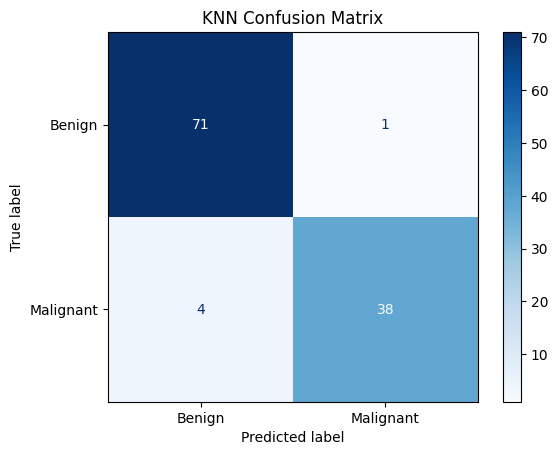

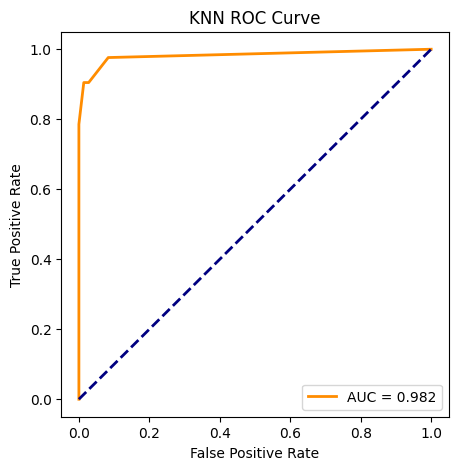

In [27]:
pipe_knn = Pipeline([
    ('pre', pre),  # scaling
    ('clf', KNeighborsClassifier(n_neighbors=5))   #model
])

pipe_knn.fit(X_train, y_train)   #Training part

knn_metrics = eval_model("KNN", pipe_knn, X_test, y_test)   # evaluate

# Random Forest


Random Forest
accuracy: 0.974
precision: 1.000
recall: 0.929
f1: 0.963


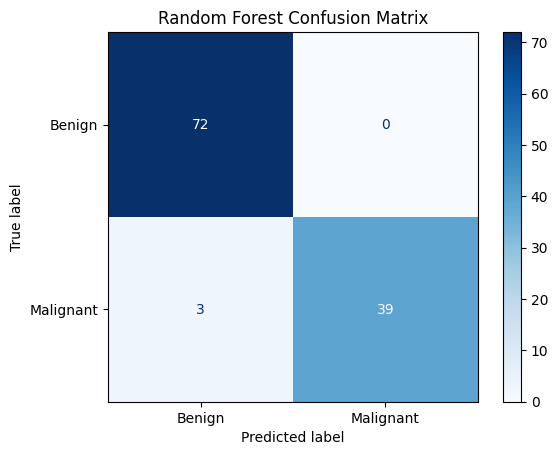

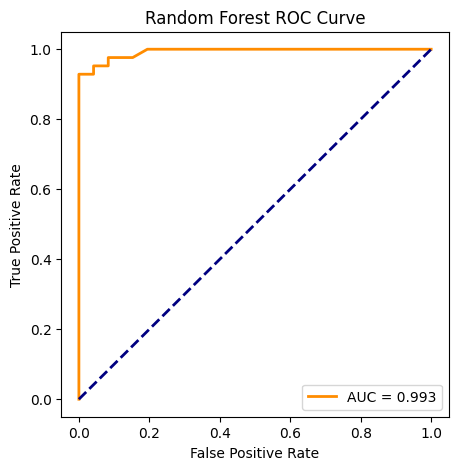

In [28]:
pipe_rf = Pipeline([
    ('pre', pre),   # scaling
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE))   #model
])

pipe_rf.fit(X_train, y_train)     #Training part

rf_metrics = eval_model("Random Forest", pipe_rf, X_test, y_test)   # evaluate

# Support Vector Machines (SVM)


SVM
accuracy: 0.974
precision: 1.000
recall: 0.929
f1: 0.963


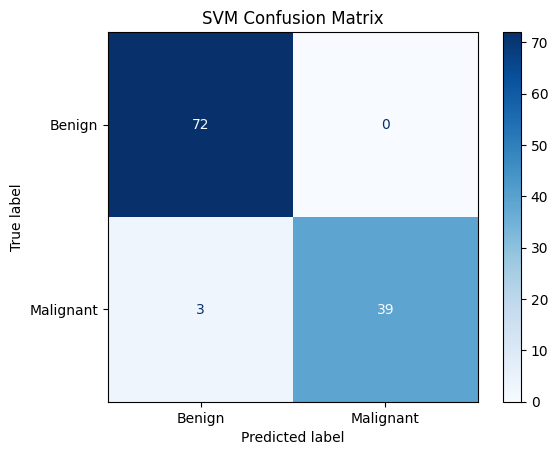

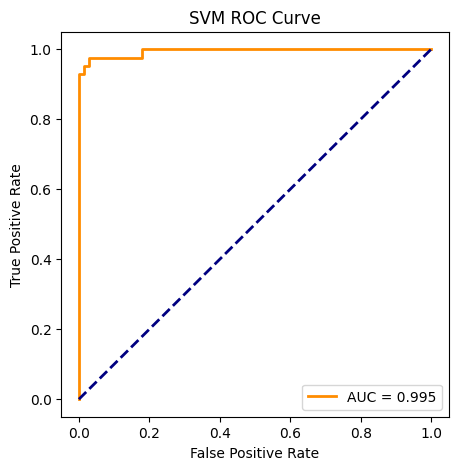

In [29]:
pipe_svm = Pipeline([
    ('pre', pre),
    ('clf', SVC(probability=True))
])

pipe_svm.fit(X_train, y_train)

svm_metrics = eval_model("SVM", pipe_svm, X_test, y_test)

**Which is the best model ?**

Random Forest and SVM achieved the best overall performance

In [30]:
results = pd.DataFrame([
    lr_metrics,
    knn_metrics,
    rf_metrics,
    svm_metrics
], index=[
    "Logistic Regression",
    "KNN",
    "Random Forest",
    "SVM"
])

results

,accuracy,precision,recall,f1
Logistic Regression,0.964912,0.975000,0.928571,0.951220
KNN,0.956140,0.974359,0.904762,0.938272
Random Forest,0.973684,1.000000,0.928571,0.962963
SVM,0.973684,1.000000,0.928571,0.962963


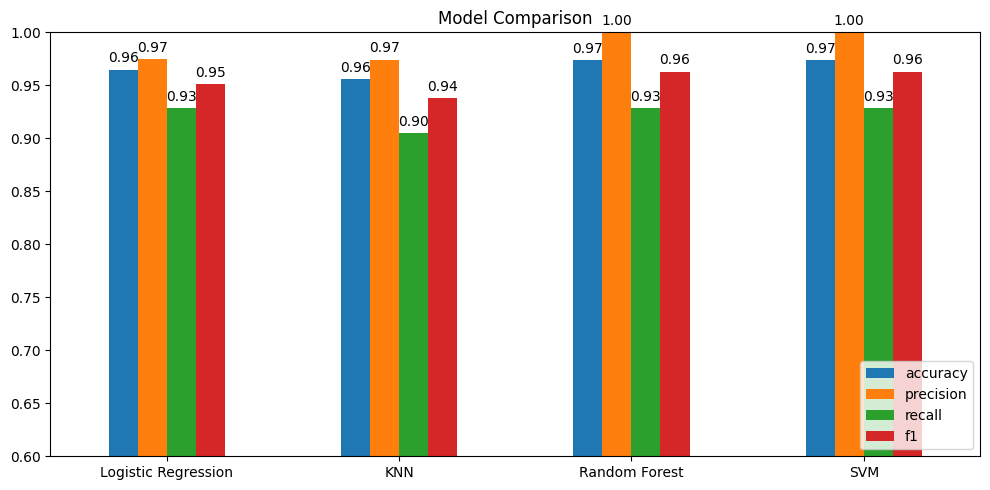

In [31]:
ax = results.plot(kind='bar', figsize=(10, 5))

plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

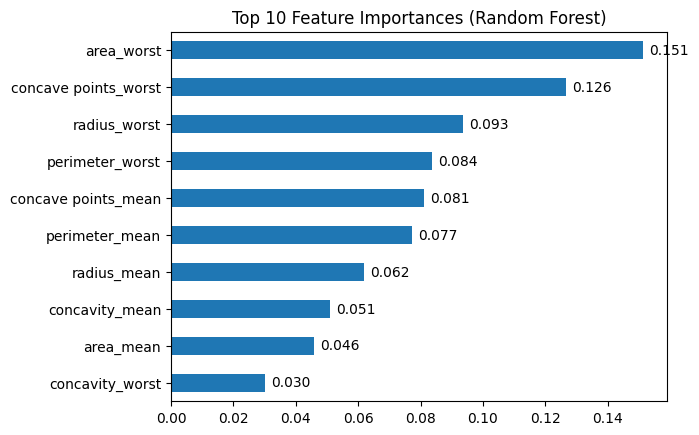

In [32]:
#  With Random Forest:

# model trained from pipeline
rf_model = pipe_rf.named_steps['clf']

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot top 10
feat_imp_top = feat_imp.head(10)
ax = feat_imp_top.plot(kind='barh')

for i, v in enumerate(feat_imp_top):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')

plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()


# Feature importance results are consistent with correlation analysis

# Final Conclusion
Four classification models were applied to predict whether a tumor is malignant or benign, using the Breast Cancer dataset.

All models performed well in the classification task... But Random Forest and SVM achieved the best overall performance, particularly in recall and F1-score, indicating a strong ability to correctly identify malignant cases.

In a medical context, recall is especially important: missing a malignant tumor (false negative) has serious consequences.

Feature importance analysis revealed that variables related to tumor size and extreme measurements (such as radius, perimeter, and area in their "worst" values) have the greatest impact on predictions. This aligns with domain knowledge, as more irregular and larger tumors are more likely to be malignant.